In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded=files.upload()


Saving insurance_cost_forecasting_100k.csv to insurance_cost_forecasting_100k.csv


In [3]:
df=pd.read_csv("/content/insurance_cost_forecasting_100k.csv")

In [4]:
df.head()

,Age,Gender,BMI,Annual_Income,Occupation,Marital_Status,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,Chronic_Disease,Blood_Pressure,Cholesterol,Diabetes,Region,Insurance_Plan,Coverage_Level,Previous_Claims,Hospital_Visits,Medical_Cost
0,56,Male,33.3,2928567,IT,Married,No,Yes,1-2 Days,No,Normal,Normal,No,East,Standard,Low,2,0,18442.16
1,46,Female,35.6,2435258,Teacher,Married,No,Yes,3-5 Days,No,High,Normal,No,West,Basic,Low,1,2,22040.92
2,32,Male,26.3,2049641,Business,Single,No,Yes,Never,No,High,Normal,Yes,West,Basic,Medium,2,2,27866.66
3,60,Male,27.9,307364,Government,Married,No,No,3-5 Days,No,High,Normal,No,East,Basic,Low,0,1,20176.80
4,25,Male,37.5,2092782,Doctor,Single,No,Yes,1-2 Days,No,Normal,High,No,North,Standard,Low,3,2,22814.60


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Age                  100000 non-null  int64  
 1   Gender               100000 non-null  object 
 2   BMI                  100000 non-null  float64
 3   Annual_Income        100000 non-null  int64  
 4   Occupation           100000 non-null  object 
 5   Marital_Status       100000 non-null  object 
 6   Smoking_Status       100000 non-null  object 
 7   Alcohol_Consumption  100000 non-null  object 
 8   Exercise_Frequency   100000 non-null  object 
 9   Chronic_Disease      100000 non-null  object 
 10  Blood_Pressure       100000 non-null  object 
 11  Cholesterol          100000 non-null  object 
 12  Diabetes             100000 non-null  object 
 13  Region               100000 non-null  object 
 14  Insurance_Plan       100000 non-null  object 
 15  Coverage_Level    

In [6]:
df.shape

(100000, 19)

In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Annual_Income,0
Occupation,0
Marital_Status,0
Smoking_Status,0
Alcohol_Consumption,0
Exercise_Frequency,0
Chronic_Disease,0


In [9]:
df.dtypes

,0
Age,int64
Gender,object
BMI,float64
Annual_Income,int64
Occupation,object
Marital_Status,object
Smoking_Status,object
Alcohol_Consumption,object
Exercise_Frequency,object
Chronic_Disease,object


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Annual_Income', 'Occupation', 'Marital_Status',
       'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency',
       'Chronic_Disease', 'Blood_Pressure', 'Cholesterol', 'Diabetes',
       'Region', 'Insurance_Plan', 'Coverage_Level', 'Previous_Claims',
       'Hospital_Visits', 'Medical_Cost'],
      dtype='object')

In [20]:
df['Age_BMI_Interaction'] = df['Age'] * df['BMI']


categorical_cols_to_encode = [
    'Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Exercise_Frequency',
    'Chronic_Disease', 'Blood_Pressure', 'Cholesterol', 'Diabetes',
    'Region', 'Insurance_Plan', 'Coverage_Level'
]

df_processed = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

df_processed = df_processed.drop(columns=['Occupation', 'Marital_Status'])

print(f"Original DataFrame shape: {df.shape}")
print(f"Processed DataFrame shape: {df_processed.shape}")
display(df_processed.head())

print(f"Number of columns in df_processed: {df_processed.shape[1]}")

Original DataFrame shape: (100000, 20)
Processed DataFrame shape: (100000, 25)


,Age,BMI,Annual_Income,Previous_Claims,Hospital_Visits,Medical_Cost,Age_BMI_Interaction,Gender_Male,Smoking_Status_Yes,Alcohol_Consumption_Yes,...,Blood_Pressure_Normal,Cholesterol_Normal,Diabetes_Yes,Region_North,Region_South,Region_West,Insurance_Plan_Premium,Insurance_Plan_Standard,Coverage_Level_Low,Coverage_Level_Medium
0,56,33.3,2928567,2,0,18442.16,1864.8,True,False,True,...,True,True,False,False,False,False,False,True,True,False
1,46,35.6,2435258,1,2,22040.92,1637.6,False,False,True,...,False,True,False,False,False,True,False,False,True,False
2,32,26.3,2049641,2,2,27866.66,841.6,True,False,True,...,False,True,True,False,False,True,False,False,False,True
3,60,27.9,307364,0,1,20176.80,1674.0,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,25,37.5,2092782,3,2,22814.60,937.5,True,False,True,...,True,False,False,True,False,False,False,True,True,False


Number of columns in df_processed: 25


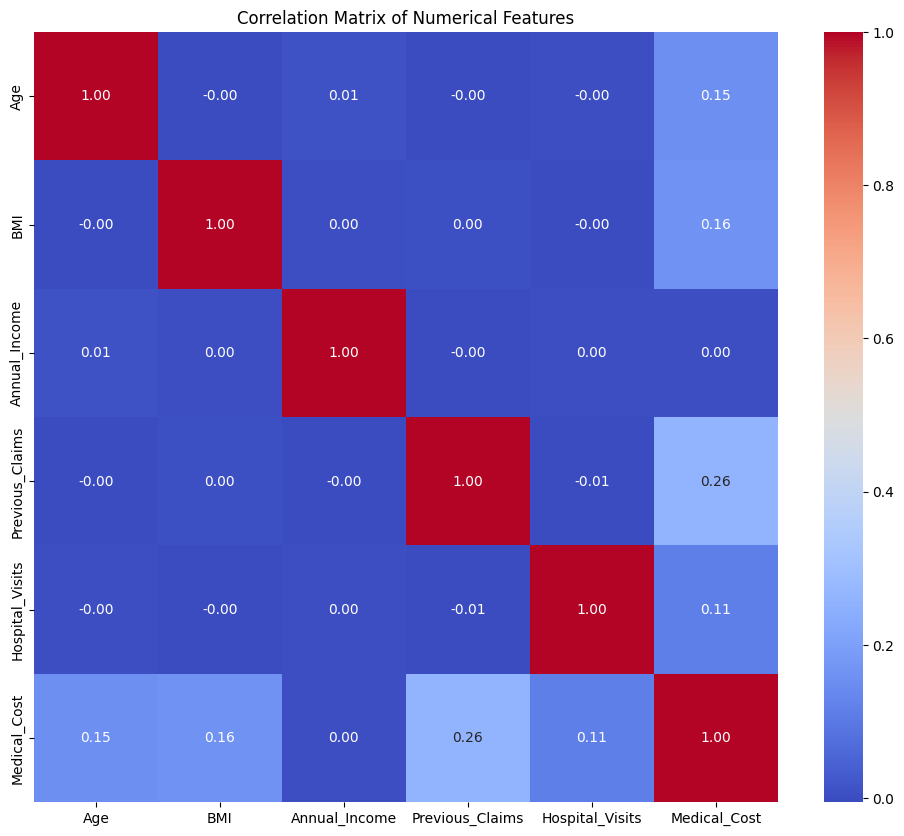

In [17]:
numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df_encoded[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [12]:
display(df.describe())

,Age,BMI,Annual_Income,Previous_Claims,Hospital_Visits,Medical_Cost
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.00000,100000.000000
mean,41.541430,28.015271,1.597467e+06,1.198160,2.99949,27281.492765
std,13.824567,6.927243,8.085159e+05,1.098173,1.73607,10824.575238
min,18.000000,16.000000,2.000040e+05,0.000000,0.00000,2000.000000
25%,30.000000,22.000000,8.955075e+05,0.000000,2.00000,19028.070000
50%,42.000000,28.000000,1.598205e+06,1.000000,3.00000,25408.775000
75%,54.000000,34.000000,2.292931e+06,2.000000,4.00000,34277.185000
max,65.000000,40.000000,2.999986e+06,7.000000,12.00000,78894.600000


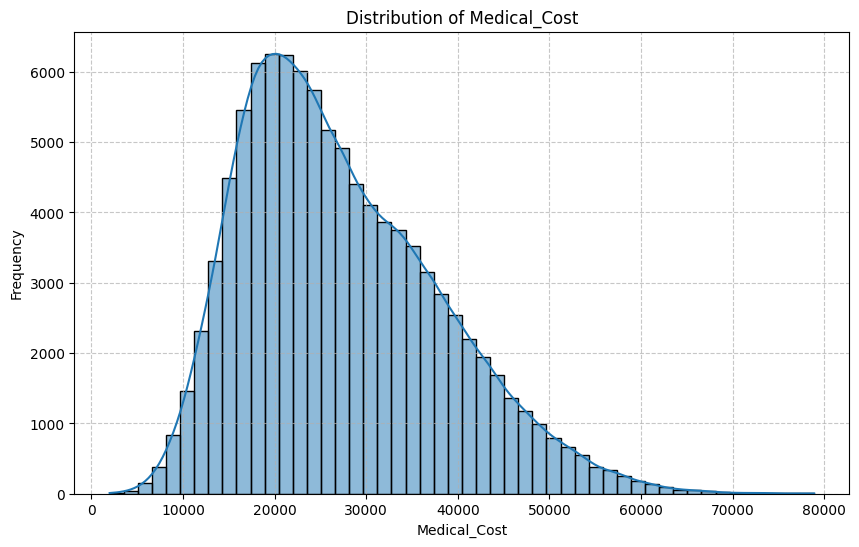

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Medical_Cost'], kde=True, bins=50)
plt.title('Distribution of Medical_Cost')
plt.xlabel('Medical_Cost')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Value counts for Gender:


,count
Gender,
Male,50159
Female,49841


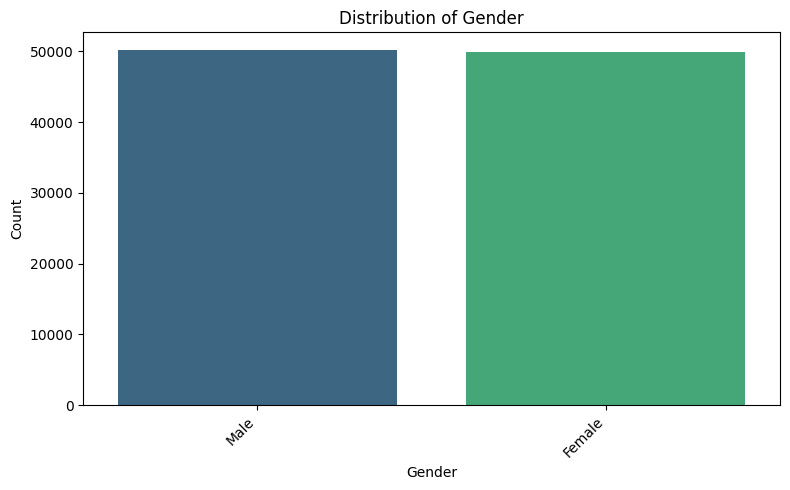


Value counts for Occupation:


,count
Occupation,
Government,14563
Business,14315
Doctor,14294
Engineer,14265
Student,14237
Teacher,14201
IT,14125


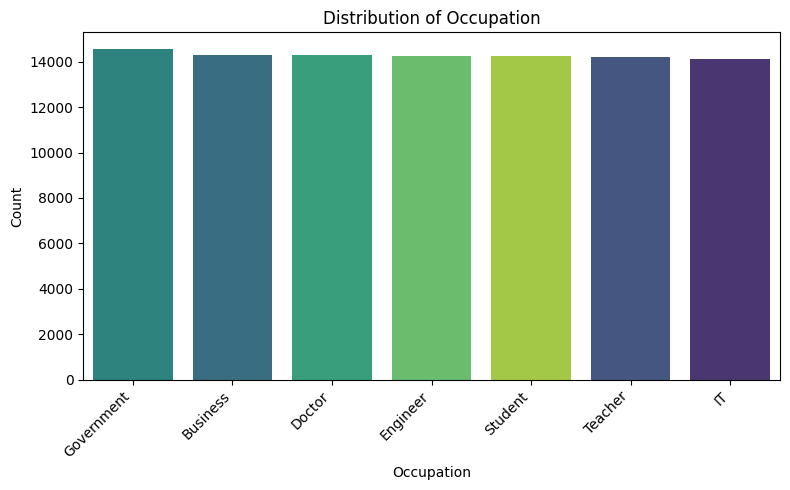


Value counts for Marital_Status:


,count
Marital_Status,
Married,55046
Single,44954


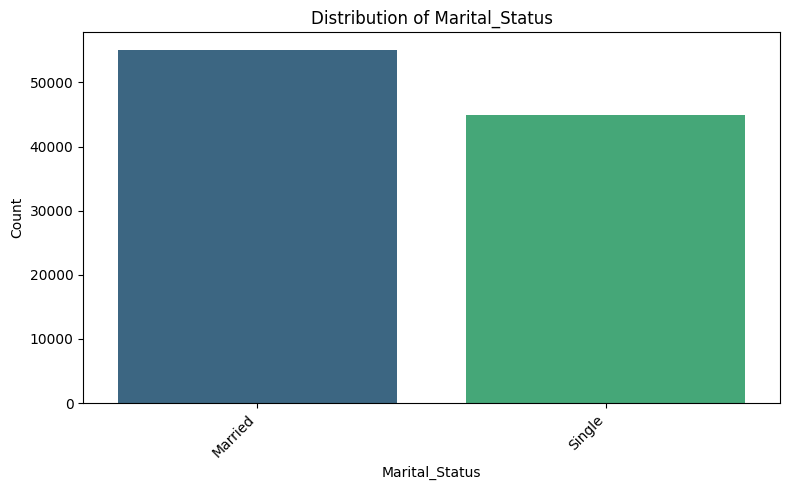


Value counts for Smoking_Status:


,count
Smoking_Status,
No,80184
Yes,19816


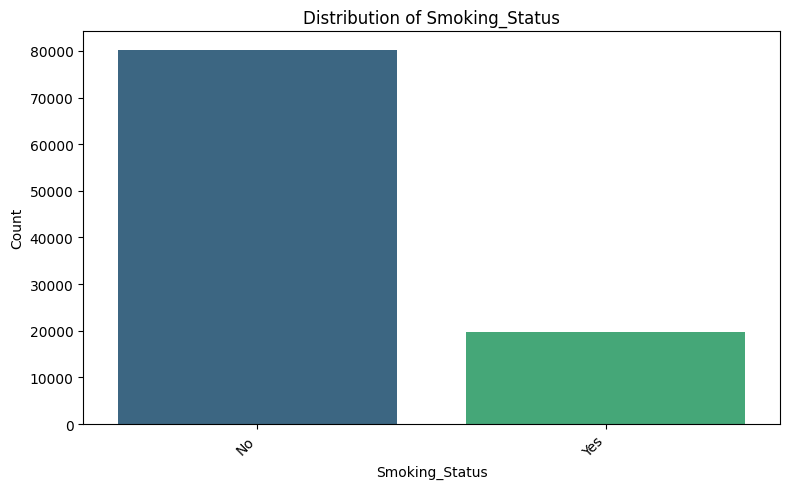


Value counts for Alcohol_Consumption:


,count
Alcohol_Consumption,
No,64797
Yes,35203


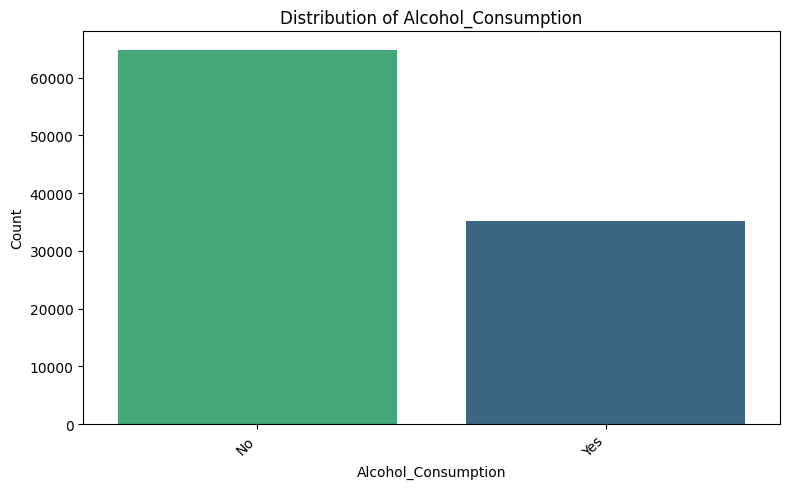


Value counts for Exercise_Frequency:


,count
Exercise_Frequency,
1-2 Days,35008
3-5 Days,35007
Daily,15055
Never,14930


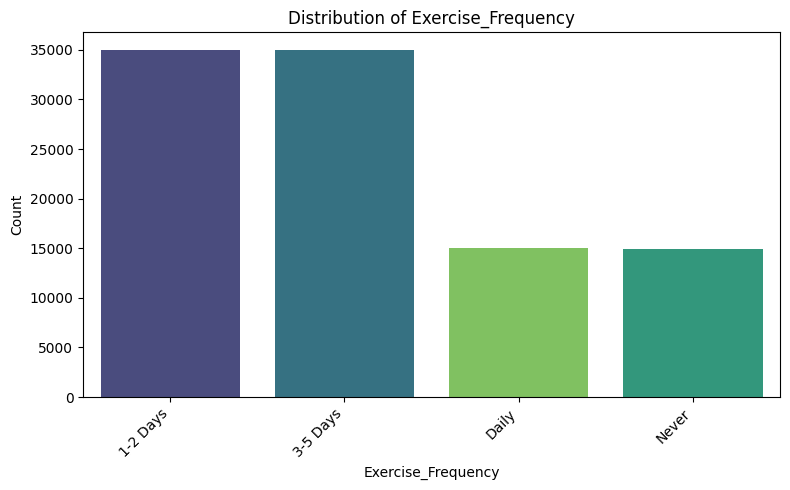


Value counts for Chronic_Disease:


,count
Chronic_Disease,
No,82196
Yes,17804


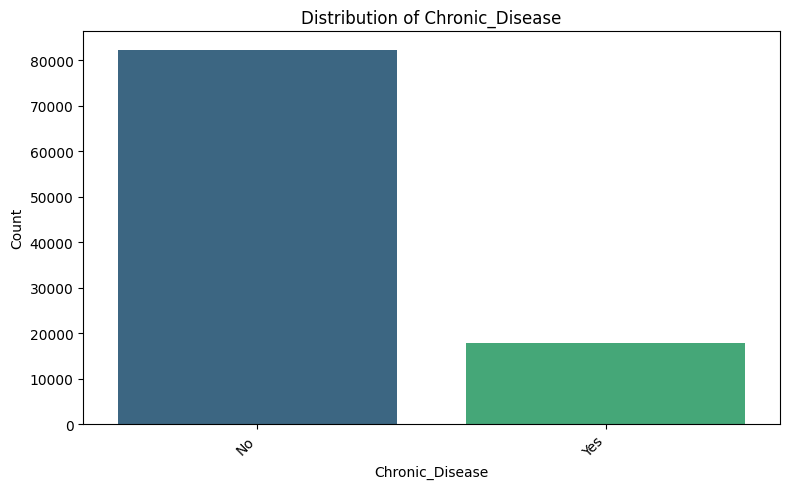


Value counts for Blood_Pressure:


,count
Blood_Pressure,
Normal,69893
High,22050
Low,8057


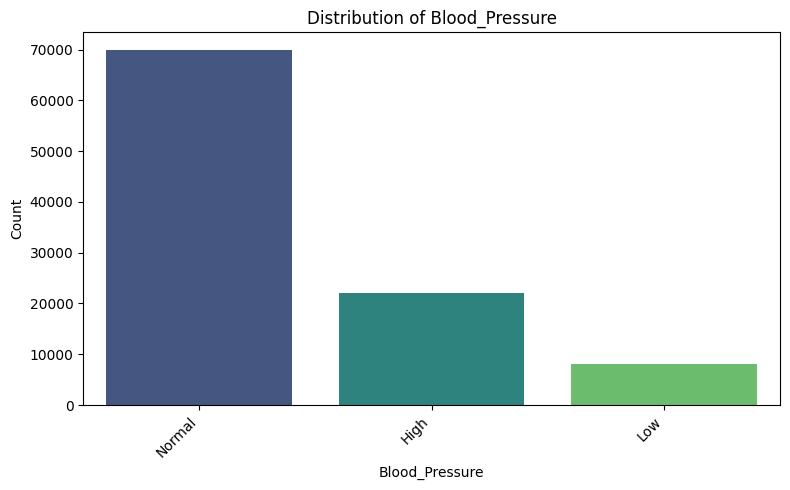


Value counts for Cholesterol:


,count
Cholesterol,
Normal,71973
High,28027


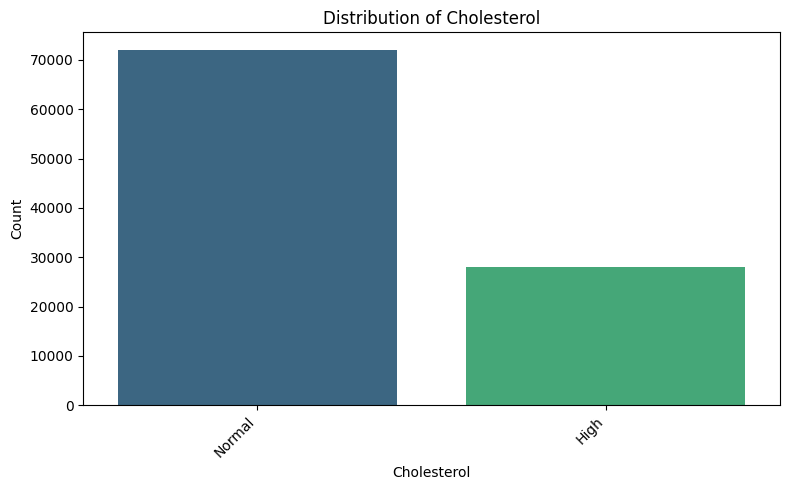


Value counts for Diabetes:


,count
Diabetes,
No,88053
Yes,11947


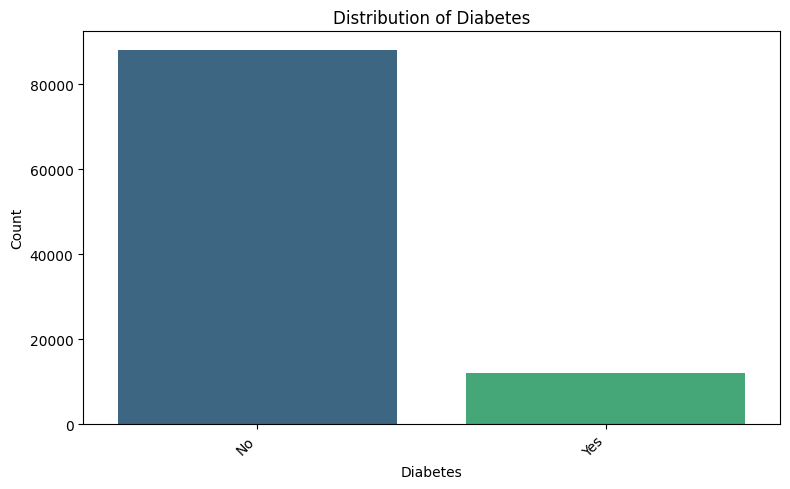


Value counts for Region:


,count
Region,
East,25135
North,25026
South,24922
West,24917


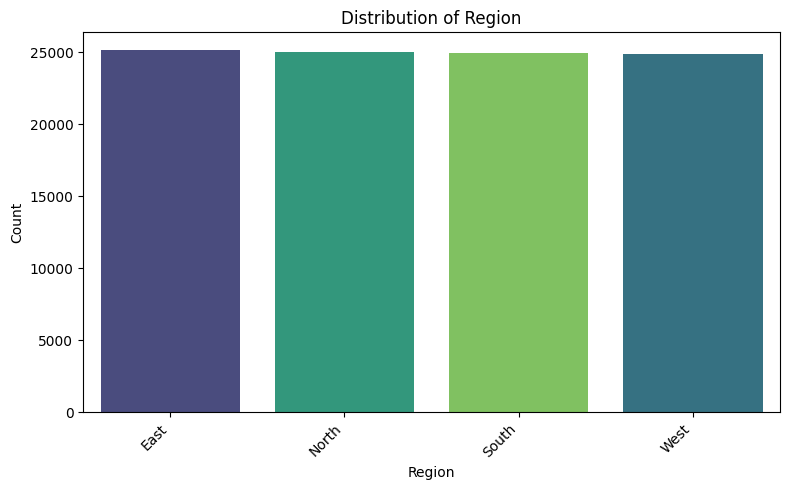


Value counts for Insurance_Plan:


,count
Insurance_Plan,
Basic,40199
Standard,39799
Premium,20002


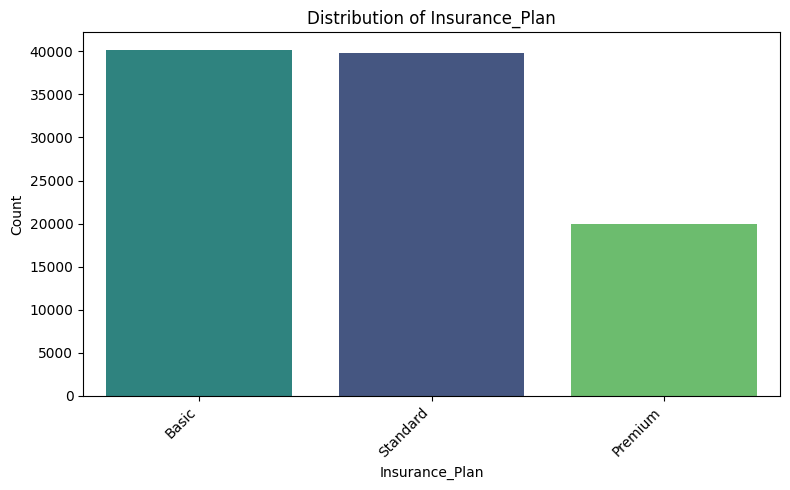


Value counts for Coverage_Level:


,count
Coverage_Level,
Medium,45195
Low,34964
High,19841


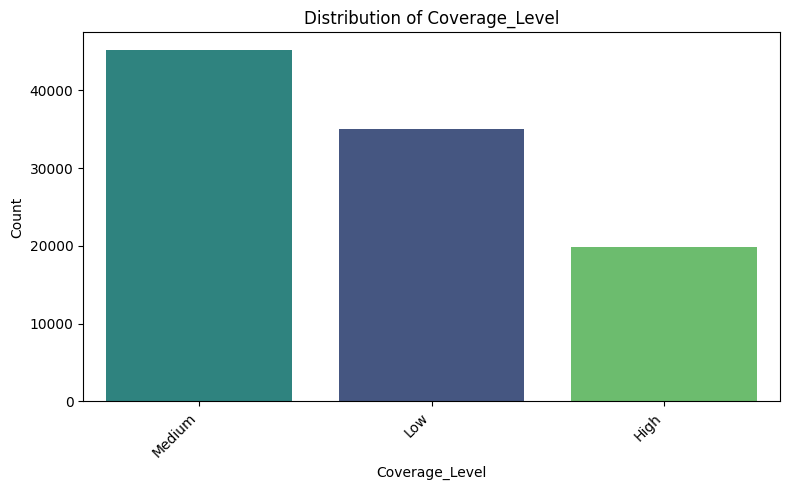

In [15]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts())
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue=col, palette='viridis', order=df[col].value_counts().index, legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
X = df_processed.drop('Medical_Cost', axis=1)
y = df_processed['Medical_Cost']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (80000, 24)
X_test shape: (20000, 24)
y_train shape: (80000,)
y_test shape: (20000,)


In [22]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_regressor.fit(X_train, y_train)

print("Random Forest Regressor training complete.")

Random Forest Regressor training complete.


In [23]:
y_pred = rf_regressor.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R-squared (Accuracy): {r2:.4f}")

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared (Accuracy): 0.9302
Root Mean Squared Error (RMSE): 2876.57


In [24]:
predictions_df = pd.DataFrame({'Actual Medical Cost': y_test, 'Predicted Medical Cost': y_pred})
display(predictions_df.head(10))

,Actual Medical Cost,Predicted Medical Cost
75721,20933.15,22475.5766
80184,29687.05,27222.0519
19864,11089.01,15746.2989
76699,40841.89,41036.6618
92991,30790.49,27975.0976
76434,19358.96,21307.8156
84004,16684.16,20044.3280
80917,38304.77,38463.3675
60767,16946.31,19268.2047
50074,31713.27,32814.2491
